# POMDP Candidate Evaluation

Purpose: Evaluate belief-selected candidate pools across observation presets and compare against the full-state oracle when available.

Role in project: canonical POMDP analysis notebook

Inputs:
- mixed VAE candidate pool
- full-state oracle run artifacts

Outputs:
- selection/evaluation runs and summary tables under `results/notebook-results/pomdp_candidate_eval/`

Expected runtime: long when rerunning selection and evaluation.

Notes:
- Existing-run configuration is available for reviewing prior outputs without recomputation.


## Imports And Repo Setup


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

# Resolve repo root when this notebook is launched from either repo root or notebooks/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "convoy_sim").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json

import matplotlib.pyplot as plt
import pandas as pd


from convoy_sim.realism import get_attacker_observation_config
from experiments.evaluate_attack_candidate_pool import evaluate_candidate_pool
from experiments.run_pomdp_candidate_selector import run_belief_selector

METRIC_FIG_FACE = "lightgrey"
METRIC_AX_FACE = "lightgrey"
METRIC_GRID_COLOR = "lightgrey"


def style_metric_ax(ax, title: str, *, xlabel: str = "", ylabel: str = "", grid_axis: str = "y"):
    ax.set_title(title, fontsize=12, weight="bold")
    ax.set_facecolor(METRIC_AX_FACE)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, axis=grid_axis, color=METRIC_GRID_COLOR, alpha=0.45, linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)


## Configuration


In [2]:
NOTEBOOK_NAME = "pomdp_candidate_eval"

CANDIDATE_PATH = PROJECT_ROOT / "results" / "notebook-results" / "vae_source_comparison" / "candidate_pools" / "mixed_curated70_random30_hit_candidates.jsonl"
FULL_STATE_RUN_DIR = PROJECT_ROOT / "results" / "runs" / "candidate_pool_eval" / "20260512_144030_vae_final_baseline_mixed_vae"

OBSERVATION_PRESETS = ["good_contact", "baseline_night", "poor_contact"]
OBSERVATION_SEEDS = [1945, 1946, 1947, 1948, 1949]
MAX_PROFILES = 1000
TOP_K = 25

RUN_SELECTION = True
RUN_MONTE_CARLO_EVAL = True

CONVOY_PROFILE = "convoy_layout_1"
EVAL_SEEDS = [1942, 1943, 1944]
N_TRIALS_PER_SEED = 10
T_MAX = 400.0
OBJECTIVE_CFG = {"preset": "balanced_default"}

OUTPUT_ROOT = PROJECT_ROOT / "results" / "notebook-results" / "pomdp_candidate_eval" / "runs"


In [3]:
preset_rows = []
for preset in OBSERVATION_PRESETS:
    cfg = get_attacker_observation_config(preset)
    row = {"preset": preset}
    row.update(cfg.to_dict())
    preset_rows.append(row)

pd.DataFrame(preset_rows)


,preset,bearing_sigma_rad,range_sigma_m,heading_sigma_rad,speed_sigma_mps,contact_count_sigma,formation_width_sigma_m,formation_depth_sigma_m,class_count_sigma,contact_detection_fraction,contact_detection_fraction_sigma
0,good_contact,0.025,80.0,0.035,0.3,0.25,100.0,120.0,0.5,0.85,0.05
1,baseline_night,0.040,120.0,0.060,0.5,0.40,180.0,200.0,0.8,0.65,0.10
2,poor_contact,0.090,300.0,0.120,1.0,1.50,450.0,500.0,1.5,0.35,0.18


## Belief-Limited Selection

This ranks the mixed VAE candidate pool under every observation preset and observation seed. Each run writes a top-k JSONL candidate pool that can be passed directly into the existing Monte Carlo evaluator.


In [4]:
selection_runs: list[dict] = []

if RUN_SELECTION:
    for preset in OBSERVATION_PRESETS:
        for observation_seed in OBSERVATION_SEEDS:
            run_dir = run_belief_selector(
                candidate_path=CANDIDATE_PATH,
                project_root=PROJECT_ROOT,
                output_root=OUTPUT_ROOT,
                run_name=f"pomdp_{preset}_seed{observation_seed}_notebook",
                convoy_profile=CONVOY_PROFILE,
                max_profiles=MAX_PROFILES,
                top_k=TOP_K,
                seed=int(observation_seed),
                observation_preset=preset,
            )
            selection_runs.append({
                "preset": preset,
                "observation_seed": int(observation_seed),
                "selection_dir": run_dir,
            })
            print(f"{preset} seed={observation_seed}: {run_dir}")
else:
    selection_runs = [
        # {"preset": "good_contact", "observation_seed": 1945, "selection_dir": PROJECT_ROOT / "results/runs/pomdp_candidate_selector/<existing_run>"},
    ]

pd.DataFrame(selection_runs)


good_contact seed=1945: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/pomdp_candidate_selector/20260612_134724_pomdp_good_contact_seed1945_notebook
good_contact seed=1946: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/pomdp_candidate_selector/20260612_134725_pomdp_good_contact_seed1946_notebook
good_contact seed=1947: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/pomdp_candidate_selector/20260612_134725_pomdp_good_contact_seed1947_notebook
good_contact seed=1948: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/pomdp_candidate_selector/20260612_134725_pomdp_good_contact_seed1948_notebook
good_contact seed=1949: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/pomdp_candidate_selector/20260612_134725_pomdp_good_contact_seed1949_notebook
baseline_night seed=1945: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/pomdp_candidate_selector/20260612_134726_pomdp_baseline_night_seed19

,preset,observation_seed,selection_dir
0,good_contact,1945,/Users/matthewplambeck/Desktop/Convoy Layout P...
1,good_contact,1946,/Users/matthewplambeck/Desktop/Convoy Layout P...
2,good_contact,1947,/Users/matthewplambeck/Desktop/Convoy Layout P...
3,good_contact,1948,/Users/matthewplambeck/Desktop/Convoy Layout P...
4,good_contact,1949,/Users/matthewplambeck/Desktop/Convoy Layout P...
5,baseline_night,1945,/Users/matthewplambeck/Desktop/Convoy Layout P...
6,baseline_night,1946,/Users/matthewplambeck/Desktop/Convoy Layout P...
7,baseline_night,1947,/Users/matthewplambeck/Desktop/Convoy Layout P...
8,baseline_night,1948,/Users/matthewplambeck/Desktop/Convoy Layout P...
9,baseline_night,1949,/Users/matthewplambeck/Desktop/Convoy Layout P...


In [5]:
belief_tables = []
for item in selection_runs:
    df = pd.read_csv(item["selection_dir"] / "belief_ranked_candidates.csv")
    df.insert(0, "observation_seed", int(item["observation_seed"]))
    df.insert(0, "preset", str(item["preset"]))
    belief_tables.append(df)

belief_df = pd.concat(belief_tables, ignore_index=True) if belief_tables else pd.DataFrame()
belief_df.head(10)


,preset,observation_seed,profile_id,name,belief_score,u_pos_x,u_pos_y,estimated_range_m,estimated_bearing_rad,estimated_convoy_heading_rad,...,spawn_region,approach_side,inside_convoy_envelope,spread_rad,launch_delay_s,salvo_interval_s,u_boat_initial_speed_mps,candidate_source_label,selector_method,belief_rank
0,good_contact,1945,VAE001218,vae_candidate_001218,0.921535,469.571960,-2328.467773,2286.420593,1.774422,0.006002,...,inside_convoy_envelope,inside,True,0.051890,1.279724,2.961656,1.263105,vae_candidate_pool_v1,belief_limited_heuristic_v1,1
1,good_contact,1945,VAE000995,vae_candidate_000995,0.915292,551.371948,2318.941406,2258.969870,-1.789800,0.001166,...,inside_convoy_envelope,inside,True,0.124146,1.799432,1.516157,1.814563,vae_candidate_pool_v1,belief_limited_heuristic_v1,2
2,good_contact,1945,VAE001061,vae_candidate_001061,0.910223,-699.750061,1907.180420,2011.705800,-1.229123,0.023040,...,inside_convoy_envelope,inside,True,0.067182,2.034932,1.501374,1.295147,vae_candidate_pool_v1,belief_limited_heuristic_v1,3
3,good_contact,1945,VAE000435,vae_candidate_000435,0.909328,603.477539,3167.550049,3002.227107,-1.732674,0.033638,...,inside_convoy_envelope,inside,True,0.072438,2.234018,1.506572,1.921293,vae_candidate_pool_v1,belief_limited_heuristic_v1,4
4,good_contact,1945,VAE001091,vae_candidate_001091,0.908928,261.502441,2069.897461,2096.827929,-1.698847,-0.013791,...,inside_convoy_envelope,inside,True,0.093518,0.880318,2.317576,1.786740,vae_candidate_pool_v1,belief_limited_heuristic_v1,5
5,good_contact,1945,VAE000766,vae_candidate_000766,0.908141,-143.002197,-2080.208984,2222.979621,1.496577,0.042811,...,inside_convoy_envelope,inside,True,0.098095,0.858272,2.094674,1.110730,vae_candidate_pool_v1,belief_limited_heuristic_v1,6
6,good_contact,1945,VAE001110,vae_candidate_001110,0.907024,-360.172180,-2530.086670,2580.190983,1.422846,0.041746,...,inside_convoy_envelope,inside,True,0.048014,2.304520,2.568442,1.622840,vae_candidate_pool_v1,belief_limited_heuristic_v1,7
7,good_contact,1945,VAE000775,vae_candidate_000775,0.906571,632.506287,2150.013184,2208.824655,-1.859950,-0.013371,...,inside_convoy_envelope,inside,True,0.061793,2.074244,2.413447,1.251240,vae_candidate_pool_v1,belief_limited_heuristic_v1,8
8,good_contact,1945,VAE000213,vae_candidate_000213,0.905744,-319.361511,-2152.106445,2064.678746,1.433554,0.033907,...,inside_convoy_envelope,inside,True,0.054060,0.688713,1.886062,1.550213,vae_candidate_pool_v1,belief_limited_heuristic_v1,9
9,good_contact,1945,VAE000820,vae_candidate_000820,0.904930,1121.855103,-1983.941406,2401.060557,2.074440,0.009249,...,inside_convoy_envelope,inside,True,0.082911,1.456425,2.344119,1.631629,vae_candidate_pool_v1,belief_limited_heuristic_v1,10


## Evaluate Selected Top-K Candidates

Each selected top-k pool is evaluated with the same scored Monte Carlo pipeline used by the full-state attacker baseline.


In [6]:
eval_runs: list[dict] = []

if RUN_MONTE_CARLO_EVAL:
    for item in selection_runs:
        preset = str(item["preset"])
        observation_seed = int(item["observation_seed"])
        selected_pool = item["selection_dir"] / "top_belief_candidate_pool.jsonl"
        run_dir = evaluate_candidate_pool(
            candidate_path=selected_pool,
            project_root=PROJECT_ROOT,
            output_root=OUTPUT_ROOT,
            run_name=f"pomdp_{preset}_seed{observation_seed}_top{TOP_K}_eval_notebook",
            convoy_profile=CONVOY_PROFILE,
            max_profiles=None,
            top_k=TOP_K,
            seeds=EVAL_SEEDS,
            n_trials_per_seed=N_TRIALS_PER_SEED,
            t_max=T_MAX,
            max_hits_per_torpedo=1,
            objective_cfg=OBJECTIVE_CFG,
        )
        eval_runs.append({
            "preset": preset,
            "observation_seed": observation_seed,
            "eval_dir": run_dir,
        })
        print(f"{preset} seed={observation_seed}: {run_dir}")
else:
    eval_runs = [
        # {"preset": "good_contact", "observation_seed": 1945, "eval_dir": PROJECT_ROOT / "results/runs/candidate_pool_eval/<existing_run>"},
    ]

pd.DataFrame(eval_runs)


good_contact seed=1945: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/candidate_pool_eval/20260612_134728_pomdp_good_contact_seed1945_top25_eval_notebook
good_contact seed=1946: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/candidate_pool_eval/20260612_134733_pomdp_good_contact_seed1946_top25_eval_notebook
good_contact seed=1947: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/candidate_pool_eval/20260612_134737_pomdp_good_contact_seed1947_top25_eval_notebook
good_contact seed=1948: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/candidate_pool_eval/20260612_134742_pomdp_good_contact_seed1948_top25_eval_notebook
good_contact seed=1949: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/candidate_pool_eval/20260612_134746_pomdp_good_contact_seed1949_top25_eval_notebook
baseline_night seed=1945: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/candidate_pool_eval/20260612_134751_po

,preset,observation_seed,eval_dir
0,good_contact,1945,/Users/matthewplambeck/Desktop/Convoy Layout P...
1,good_contact,1946,/Users/matthewplambeck/Desktop/Convoy Layout P...
2,good_contact,1947,/Users/matthewplambeck/Desktop/Convoy Layout P...
3,good_contact,1948,/Users/matthewplambeck/Desktop/Convoy Layout P...
4,good_contact,1949,/Users/matthewplambeck/Desktop/Convoy Layout P...
5,baseline_night,1945,/Users/matthewplambeck/Desktop/Convoy Layout P...
6,baseline_night,1946,/Users/matthewplambeck/Desktop/Convoy Layout P...
7,baseline_night,1947,/Users/matthewplambeck/Desktop/Convoy Layout P...
8,baseline_night,1948,/Users/matthewplambeck/Desktop/Convoy Layout P...
9,baseline_night,1949,/Users/matthewplambeck/Desktop/Convoy Layout P...


## Per-Run Summary

For POMDP rows, `candidate_pool` is the belief-selected top-k pool. For the optional full-state row, `top_k` is the oracle-selected top-k from the existing full-state mixed-VAE baseline.


In [7]:
def load_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))

summary_rows = []

if FULL_STATE_RUN_DIR.exists():
    metrics = load_json(FULL_STATE_RUN_DIR / "metrics_summary.json")
    top = metrics["top_k"]
    best = metrics.get("best_candidate") or {}
    summary_rows.append({
        "selector": "full_state_oracle",
        "preset": "oracle",
        "observation_seed": -1,
        "profiles": int(top.get("profiles", TOP_K)),
        "expected_hits": float(top["expected_hits"]),
        "expected_loss": float(top.get("expected_loss", 0.0)),
        "expected_unique_ships_hit": float(top.get("expected_unique_ships_hit", 0.0)),
        "CVaR_90": float(top.get("CVaR_90", 0.0)),
        "CVaR_90_loss": float(top.get("CVaR_90_loss", 0.0)),
        "best_profile_id": str(best.get("profile_id", "")),
    })

for item in eval_runs:
    metrics = load_json(item["eval_dir"] / "metrics_summary.json")
    pool = metrics["candidate_pool"]
    best = metrics.get("best_candidate") or {}
    summary_rows.append({
        "selector": "belief_limited",
        "preset": str(item["preset"]),
        "observation_seed": int(item["observation_seed"]),
        "profiles": int(pool.get("profiles", TOP_K)),
        "expected_hits": float(pool["expected_hits"]),
        "expected_loss": float(pool.get("expected_loss", 0.0)),
        "expected_unique_ships_hit": float(pool.get("expected_unique_ships_hit", 0.0)),
        "CVaR_90": float(pool.get("CVaR_90", 0.0)),
        "CVaR_90_loss": float(pool.get("CVaR_90_loss", 0.0)),
        "best_profile_id": str(best.get("profile_id", "")),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,selector,preset,observation_seed,profiles,expected_hits,expected_loss,expected_unique_ships_hit,CVaR_90,CVaR_90_loss,best_profile_id
0,full_state_oracle,oracle,-1,25,3.850667,6.607333,3.180000,3.960000,6.880000,VAE000124
1,belief_limited,good_contact,1945,25,3.420000,4.164467,1.905333,3.648889,4.750655,VAE000732
2,belief_limited,good_contact,1946,25,3.450667,4.216600,1.929333,3.688889,4.684655,VAE000317
3,belief_limited,good_contact,1947,25,3.420000,3.790867,1.697333,3.688889,4.252655,VAE000732
4,belief_limited,good_contact,1948,25,3.556000,4.155933,1.888000,3.728889,4.610655,VAE000317
5,belief_limited,good_contact,1949,25,3.397333,4.151400,1.904000,3.688889,4.604655,VAE000317
6,belief_limited,baseline_night,1945,25,3.489333,3.958133,1.788000,3.728889,4.469200,VAE000459
7,belief_limited,baseline_night,1946,25,3.333333,4.230533,1.957333,3.648889,4.811200,VAE000317
8,belief_limited,baseline_night,1947,25,3.414667,3.605133,1.589333,3.640000,4.035455,VAE000317
9,belief_limited,baseline_night,1948,25,3.637333,3.876200,1.721333,3.808889,4.270655,VAE000317


## Preset Aggregate

This is the main comparison table. Means and standard deviations are over observation seeds; Monte Carlo seeds/trials are the same across rows.


In [8]:
metric_cols = ["expected_hits", "expected_loss", "expected_unique_ships_hit", "CVaR_90", "CVaR_90_loss"]

pomdp_df = summary_df.loc[summary_df["selector"] == "belief_limited"].copy()
agg_df = (
    pomdp_df.groupby("preset", as_index=False)[metric_cols]
    .agg(["mean", "std", "min", "max"])
)
agg_df.columns = ["preset" if col[0] == "preset" else f"{col[0]}_{col[1]}" for col in agg_df.columns]
agg_df = agg_df.reset_index(drop=True)

if FULL_STATE_RUN_DIR.exists():
    oracle_row = summary_df.loc[summary_df["selector"] == "full_state_oracle"].iloc[0]
    for metric in metric_cols:
        agg_df[f"oracle_gap_{metric}"] = float(oracle_row[metric]) - agg_df[f"{metric}_mean"]

agg_df


,preset,expected_hits_mean,expected_hits_std,expected_hits_min,expected_hits_max,expected_loss_mean,expected_loss_std,expected_loss_min,expected_loss_max,expected_unique_ships_hit_mean,...,CVaR_90_max,CVaR_90_loss_mean,CVaR_90_loss_std,CVaR_90_loss_min,CVaR_90_loss_max,oracle_gap_expected_hits,oracle_gap_expected_loss,oracle_gap_expected_unique_ships_hit,oracle_gap_CVaR_90,oracle_gap_CVaR_90_loss
0,baseline_night,3.466133,0.112066,3.333333,3.637333,3.966827,0.248788,3.605133,4.230533,1.791200,...,3.808889,4.423833,0.290798,4.035455,4.811200,0.384533,2.640507,1.388800,0.264889,2.456167
1,good_contact,3.448800,0.062855,3.397333,3.556000,4.095853,0.172481,3.790867,4.216600,1.864800,...,3.728889,4.580655,0.192857,4.252655,4.750655,0.401867,2.511480,1.315200,0.271111,2.299345
2,poor_contact,3.031200,0.155608,2.818667,3.204000,3.560787,0.181069,3.325267,3.782000,1.617333,...,3.450667,4.095367,0.160831,3.917206,4.271778,0.819467,3.046547,1.562667,0.607172,2.784633


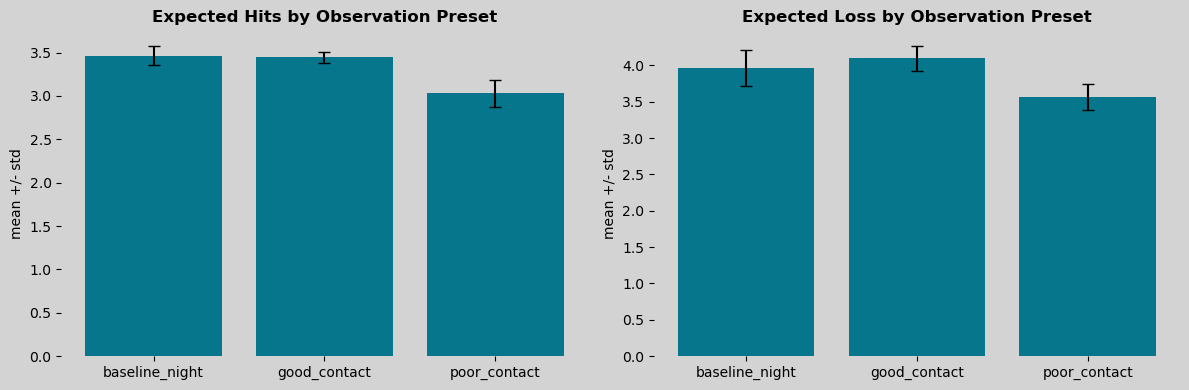

In [9]:
if len(agg_df):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor=METRIC_FIG_FACE)
    axes[0].bar(
        agg_df["preset"],
        agg_df["expected_hits_mean"],
        yerr=agg_df["expected_hits_std"],
        color="#06768d",
        # edgecolor="#000000",
        linewidth=0.8,
        capsize=4,
    )
    style_metric_ax(axes[0], "Expected Hits by Observation Preset", ylabel="mean +/- std")
    axes[1].bar(
        agg_df["preset"],
        agg_df["expected_loss_mean"],
        yerr=agg_df["expected_loss_std"],
        color="#06768d",
        # edgecolor="#000000",
        linewidth=0.8,
        capsize=4,
    )
    style_metric_ax(axes[1], "Expected Loss by Observation Preset", ylabel="mean +/- std")
    fig.subplots_adjust(wspace=0.22)
    plt.tight_layout()
    plt.show()


## Rank Overlap Diagnostics

This checks whether noisy belief selection is choosing the same candidates as the full-state Monte Carlo oracle, and whether presets are selecting meaningfully different top-k sets.


In [10]:
overlap_rows = []
if FULL_STATE_RUN_DIR.exists() and selection_runs:
    full_ranked = pd.read_csv(FULL_STATE_RUN_DIR / "ranked_candidates.csv")
    oracle_top = set(full_ranked.head(TOP_K)["profile_id"].astype(str))
    for item in selection_runs:
        belief_ranked = pd.read_csv(item["selection_dir"] / "belief_ranked_candidates.csv")
        belief_top = set(belief_ranked.head(TOP_K)["profile_id"].astype(str))
        overlap_rows.append({
            "preset": str(item["preset"]),
            "observation_seed": int(item["observation_seed"]),
            "top_k": TOP_K,
            "oracle_overlap_count": len(oracle_top & belief_top),
            "oracle_overlap_rate": len(oracle_top & belief_top) / float(TOP_K),
        })

overlap_df = pd.DataFrame(overlap_rows)
overlap_df


,preset,observation_seed,top_k,oracle_overlap_count,oracle_overlap_rate
0,good_contact,1945,25,1,0.04
1,good_contact,1946,25,2,0.08
2,good_contact,1947,25,1,0.04
3,good_contact,1948,25,2,0.08
4,good_contact,1949,25,2,0.08
5,baseline_night,1945,25,0,0.00
6,baseline_night,1946,25,2,0.08
7,baseline_night,1947,25,1,0.04
8,baseline_night,1948,25,2,0.08
9,baseline_night,1949,25,2,0.08


,index,preset,mean,std,min,max
0,0,baseline_night,0.056,0.035777,0.00,0.08
1,1,good_contact,0.064,0.021909,0.04,0.08
2,2,poor_contact,0.000,0.000000,0.00,0.00


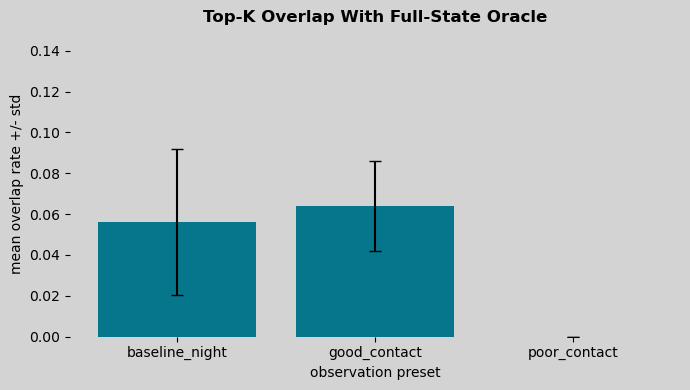

In [11]:
if len(overlap_df):
    overlap_agg = (
        overlap_df.groupby("preset", as_index=False)["oracle_overlap_rate"]
        .agg(["mean", "std", "min", "max"])
        .reset_index()
    )
    display(overlap_agg)

    fig, ax = plt.subplots(figsize=(7, 4), facecolor=METRIC_FIG_FACE)
    ax.bar(
        overlap_agg["preset"],
        overlap_agg["mean"],
        yerr=overlap_agg["std"],
        color="#06768d",
        # edgecolor="#000000",
        linewidth=0.8,
        capsize=4,
    )
    ax.set_ylim(0, 0.15)
    style_metric_ax(
        ax,
        "Top-K Overlap With Full-State Oracle",
        xlabel="observation preset",
        ylabel="mean overlap rate +/- std",
    )
    plt.tight_layout()
    plt.show()


In [12]:
preset_pair_rows = []
for observation_seed in OBSERVATION_SEEDS:
    seed_runs = [item for item in selection_runs if int(item["observation_seed"]) == int(observation_seed)]
    top_by_preset = {}
    for item in seed_runs:
        df = pd.read_csv(item["selection_dir"] / "belief_ranked_candidates.csv")
        top_by_preset[str(item["preset"])] = set(df.head(TOP_K)["profile_id"].astype(str))
    for idx, preset_a in enumerate(OBSERVATION_PRESETS):
        for preset_b in OBSERVATION_PRESETS[idx + 1:]:
            if preset_a not in top_by_preset or preset_b not in top_by_preset:
                continue
            overlap = len(top_by_preset[preset_a] & top_by_preset[preset_b])
            preset_pair_rows.append({
                "observation_seed": int(observation_seed),
                "preset_a": preset_a,
                "preset_b": preset_b,
                "overlap_count": overlap,
                "overlap_rate": overlap / float(TOP_K),
            })

preset_pair_overlap_df = pd.DataFrame(preset_pair_rows)
preset_pair_overlap_df


,observation_seed,preset_a,preset_b,overlap_count,overlap_rate
0,1945,good_contact,baseline_night,18,0.72
1,1945,good_contact,poor_contact,4,0.16
2,1945,baseline_night,poor_contact,10,0.40
3,1946,good_contact,baseline_night,20,0.80
4,1946,good_contact,poor_contact,4,0.16
5,1946,baseline_night,poor_contact,9,0.36
6,1947,good_contact,baseline_night,17,0.68
7,1947,good_contact,poor_contact,5,0.20
8,1947,baseline_night,poor_contact,8,0.32
9,1948,good_contact,baseline_night,20,0.80


## Write Compact Artifacts

This writes a compact reporting bundle for later docs, paper tables, and comparison notebooks.


In [13]:
DIAG_OUTPUT_DIR = PROJECT_ROOT / "results" / "notebook-results" / "pomdp_candidate_eval"
DIAG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

summary_csv = DIAG_OUTPUT_DIR / "pomdp_candidate_eval_summary.csv"
per_run_csv = DIAG_OUTPUT_DIR / "pomdp_candidate_eval_per_run.csv"
overlap_csv = DIAG_OUTPUT_DIR / "pomdp_candidate_eval_oracle_overlap.csv"
pair_overlap_csv = DIAG_OUTPUT_DIR / "pomdp_candidate_eval_preset_pair_overlap.csv"
summary_json = DIAG_OUTPUT_DIR / "pomdp_candidate_eval_summary.json"

agg_df.to_csv(summary_csv, index=False)
summary_df.to_csv(per_run_csv, index=False)
overlap_df.to_csv(overlap_csv, index=False)
preset_pair_overlap_df.to_csv(pair_overlap_csv, index=False)

summary_payload = {
    "workflow": "pomdp_candidate_eval_notebook",
    "candidate_path": str(CANDIDATE_PATH.relative_to(PROJECT_ROOT)),
    "full_state_run_dir": str(FULL_STATE_RUN_DIR.relative_to(PROJECT_ROOT)),
    "top_k": int(TOP_K),
    "observation_presets": list(OBSERVATION_PRESETS),
    "observation_seeds": [int(seed) for seed in OBSERVATION_SEEDS],
    "metric_columns": list(metric_cols),
    "aggregate": json.loads(agg_df.to_json(orient="records")),
    "per_run": json.loads(summary_df.to_json(orient="records")),
    "oracle_overlap": json.loads(overlap_df.to_json(orient="records")),
    "preset_pair_overlap": json.loads(preset_pair_overlap_df.to_json(orient="records")),
    "artifacts": {
        "summary_csv": summary_csv.name,
        "per_run_csv": per_run_csv.name,
        "oracle_overlap_csv": overlap_csv.name,
        "preset_pair_overlap_csv": pair_overlap_csv.name,
        "summary_json": summary_json.name,
    },
}
summary_json.write_text(json.dumps(summary_payload, indent=2) + "\n", encoding="utf-8")

{
    "summary_csv": str(summary_csv),
    "per_run_csv": str(per_run_csv),
    "oracle_overlap_csv": str(overlap_csv),
    "preset_pair_overlap_csv": str(pair_overlap_csv),
    "summary_json": str(summary_json),
}


{'summary_csv': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/notebook-results/pomdp_candidate_eval/pomdp_candidate_eval_summary.csv',
 'per_run_csv': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/notebook-results/pomdp_candidate_eval/pomdp_candidate_eval_per_run.csv',
 'oracle_overlap_csv': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/notebook-results/pomdp_candidate_eval/pomdp_candidate_eval_oracle_overlap.csv',
 'preset_pair_overlap_csv': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/notebook-results/pomdp_candidate_eval/pomdp_candidate_eval_preset_pair_overlap.csv',
 'summary_json': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/notebook-results/pomdp_candidate_eval/pomdp_candidate_eval_summary.json'}